In [ ]:
import matplotlib.pyplot as plt
import joblib as jlb

from collections import Counter
from pyclustering.cluster.clarans import clarans
from Customer_dataset import data
processed_data=data.copy()

In [2]:
print(processed_data.tail(1))

     Age  Income_Level  Gender_Male
999   38         54931            0


In [3]:
#data to list vi claran chi chap nhan list
x = processed_data.values.tolist()
print(x[0])

[23, 70541, 0]


In [4]:
#xay dung model clarans
k = 5
n_local=5
max_nei=4
Clarans_model = clarans(x, number_clusters=k, numlocal=n_local, maxneighbor=max_nei)
Clarans_model.process()

In [5]:
#lấy cluster và medoids
clusters = Clarans_model.get_clusters()
medoids = Clarans_model.get_medoids()

print("Clusters:", clusters)
print("Medoids:", medoids)

Clusters: [[5, 6, 12, 14, 22, 26, 35, 36, 37, 45, 58, 62, 65, 68, 69, 75, 80, 94, 96, 100, 110, 113, 114, 116, 121, 129, 150, 153, 162, 175, 180, 185, 186, 192, 193, 203, 208, 210, 216, 225, 230, 233, 234, 236, 242, 245, 253, 258, 264, 265, 271, 283, 285, 289, 297, 300, 304, 311, 340, 354, 365, 366, 374, 378, 380, 381, 390, 391, 408, 410, 411, 425, 449, 451, 457, 462, 463, 469, 491, 496, 499, 506, 522, 537, 552, 560, 564, 588, 598, 599, 600, 601, 610, 613, 614, 635, 638, 648, 649, 652, 661, 663, 665, 676, 682, 707, 710, 718, 723, 724, 731, 742, 746, 748, 750, 761, 763, 776, 782, 796, 803, 812, 826, 827, 833, 840, 853, 857, 861, 864, 868, 869, 871, 872, 875, 881, 883, 889, 896, 897, 900, 901, 914, 921, 922, 927, 939, 958, 963, 964, 966, 968, 989, 993, 998], [27, 43, 44, 50, 57, 63, 73, 83, 98, 102, 106, 109, 111, 126, 127, 128, 130, 132, 133, 136, 138, 144, 147, 148, 149, 159, 161, 166, 173, 179, 194, 195, 214, 218, 222, 232, 244, 247, 267, 273, 280, 295, 302, 306, 314, 315, 317, 322, 3

In [6]:
#gắn nhãn cluster đã có vào df
labels = [0] * len(data)

for cluster_id, cluster in enumerate(clusters):
    for index in cluster:
        labels[index] = cluster_id

processed_data['cluster'] = labels
print(processed_data.head(1))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

   Age  Income_Level  Gender_Male  cluster
0   23         70541            0        3

Kích thước clusters: Counter({2: 349, 4: 205, 0: 155, 3: 154, 1: 137})

2 clusters lớn nhất: [(2, 349), (4, 205)]


In [7]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [8]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

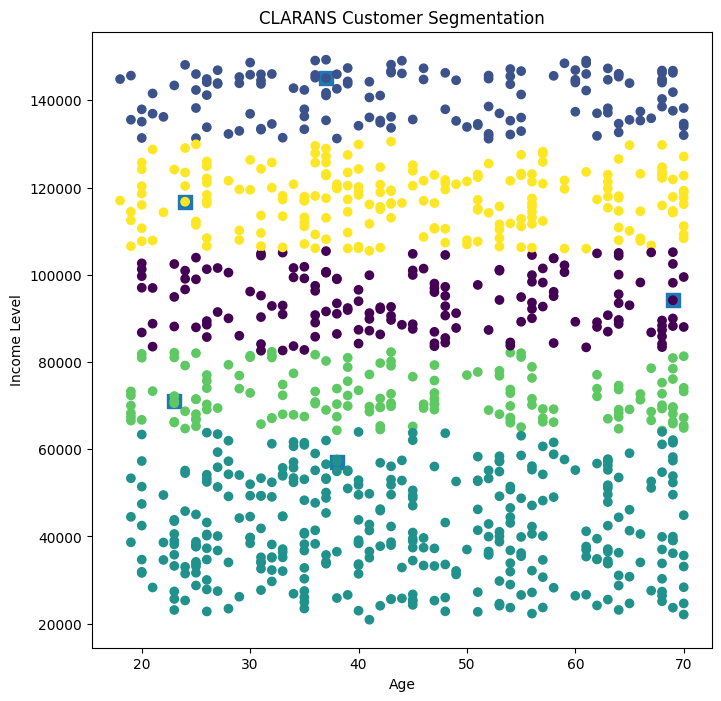

In [9]:
#hien thi model
medoid_points = processed_data.iloc[medoids]

plt.figure(figsize=(8,8))

plt.scatter(medoid_points['Age'],
            medoid_points['Income_Level'],
            marker='s',
            s=100
            )

plt.scatter(processed_data['Age'],
            processed_data['Income_Level'],
            c=processed_data['cluster'])

plt.xlabel("Age")
plt.ylabel("Income Level")
plt.title("CLARANS Customer Segmentation")

plt.show()